# Wykrywanie anomalii w MNIST

Celem notebooka jest opracowanie i przetestowanie algorytmu anomaly detection w dwóch sytuacjach:

1. na samych danych MNIST,
2. na danych MNIST z celowo dodanymi obcymi obrazkami: domkiem, buźką, literą, grzybkiem, samolotem, kreską, czterema kółkami itd.

Algorytm jest trenowany wyłącznie na normalnych obrazach cyfr. Nie uczymy go przykładów anomalii. Wykorzystujemy PCA jako prosty model typowego wyglądu cyfr oraz prototypy wyznaczone przez klasteryzację w przestrzeni PCA. Sama decyzja anomaly detection jest zaimplementowana w kodzie poniżej: obraz jest podejrzany, jeśli ma duży błąd rekonstrukcji i/lub leży daleko od najbliższego prototypu cyfry.

In [1]:
import os
os.environ.setdefault("MPLCONFIGDIR", os.path.abspath(".matplotlib-cache"))

from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
from PIL import Image, ImageDraw, ImageFilter
from sklearn.cluster import MiniBatchKMeans
from torchvision.datasets import MNIST

SEED = 2026
rng = np.random.default_rng(SEED)

plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 10

Matplotlib is building the font cache; this may take a moment.


## Dane

MNIST pobieramy przez `torchvision`. Obrazy są normalizowane do zakresu `[0, 1]` i spłaszczane do wektorów długości 784.

In [2]:
train_ds = MNIST(root="./data", train=True, download=True)
test_ds = MNIST(root="./data", train=False, download=True)

X_train_all = train_ds.data.numpy().astype(np.float32) / 255.0
y_train_all = train_ds.targets.numpy()
X_test = test_ds.data.numpy().astype(np.float32) / 255.0
y_test = test_ds.targets.numpy()

X_train_flat = X_train_all.reshape(len(X_train_all), -1)
X_test_flat = X_test.reshape(len(X_test), -1)

X_train_all.shape, X_test.shape

((60000, 28, 28), (10000, 28, 28))

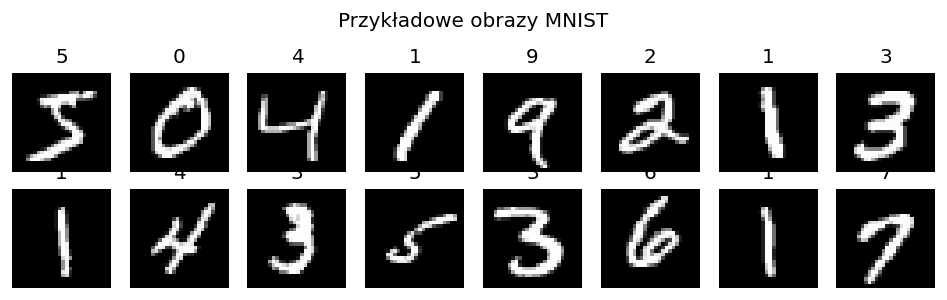

In [3]:
fig, axes = plt.subplots(2, 8, figsize=(8, 2.5))
for ax, image, label in zip(axes.ravel(), X_train_all[:16], y_train_all[:16]):
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title(str(label))
    ax.axis("off")
plt.suptitle("Przykładowe obrazy MNIST")
plt.tight_layout()

## Detektor anomalii

PCA opisuje przestrzeń typowych cyfr. Jeżeli obraz nie przypomina cyfry, zwykle trudno go dobrze odtworzyć przy użyciu ograniczonej liczby składowych głównych. Sam błąd rekonstrukcji nie wystarcza jednak zawsze, bo niektóre proste obce rysunki również są łatwe do rekonstrukcji. Dlatego dodajemy drugi składnik: odległość od najbliższego prototypu cyfry w przestrzeni PCA.

Klasteryzacja prototypów jest wykonana przez `MiniBatchKMeans`, ale wynik anomalii liczymy ręcznie:

`score(x) = robust_z(reconstruction_error(x)) + robust_z(nearest_prototype_distance(x))`.

Im większy wynik, tym bardziej nietypowy obraz.

In [4]:
def robust_center_scale(values):
    values = np.asarray(values, dtype=np.float64)
    center = np.median(values)
    mad = np.median(np.abs(values - center))
    scale = 1.4826 * mad
    if scale < 1e-12:
        scale = np.std(values) + 1e-12
    return center, scale


@dataclass
class PCADistanceAnomalyDetector:
    n_components: int = 80
    n_clusters: int = 80
    train_limit: int = 25_000
    random_state: int = SEED

    def fit(self, X):
        if self.train_limit is not None and len(X) > self.train_limit:
            local_rng = np.random.default_rng(self.random_state)
            idx = local_rng.choice(len(X), size=self.train_limit, replace=False)
            X_fit = X[idx]
        else:
            X_fit = X

        X_fit = X_fit.astype(np.float32)
        self.mean_ = X_fit.mean(axis=0)
        centered = X_fit - self.mean_

        # SVD daje składowe PCA bez korzystania z gotowego detektora anomalii.
        _, singular_values, vt = np.linalg.svd(centered, full_matrices=False)
        self.components_ = vt[:self.n_components].astype(np.float32)
        self.explained_variance_ratio_ = (singular_values[:self.n_components] ** 2).sum() / (singular_values ** 2).sum()

        latent = self.transform(X_fit)
        self.kmeans_ = MiniBatchKMeans(
            n_clusters=self.n_clusters,
            batch_size=4096,
            n_init=5,
            random_state=self.random_state,
        ).fit(latent)

        train_recon, train_distance = self.score_parts(X_fit)
        self.recon_center_, self.recon_scale_ = robust_center_scale(train_recon)
        self.distance_center_, self.distance_scale_ = robust_center_scale(train_distance)
        return self

    def transform(self, X):
        return (X.astype(np.float32) - self.mean_) @ self.components_.T

    def reconstruct(self, X):
        latent = self.transform(X)
        reconstruction = latent @ self.components_ + self.mean_
        return np.clip(reconstruction, 0.0, 1.0)

    def score_parts(self, X):
        X = X.astype(np.float32)
        latent = self.transform(X)
        reconstruction = latent @ self.components_ + self.mean_
        reconstruction_error = np.mean((X - reconstruction) ** 2, axis=1)

        centers = self.kmeans_.cluster_centers_.astype(np.float32)
        min_distances = []
        for start in range(0, len(latent), 2048):
            block = latent[start:start + 2048]
            dist2 = ((block[:, None, :] - centers[None, :, :]) ** 2).sum(axis=2)
            min_distances.append(np.sqrt(dist2.min(axis=1)))
        prototype_distance = np.concatenate(min_distances)
        return reconstruction_error, prototype_distance

    def score(self, X):
        reconstruction_error, prototype_distance = self.score_parts(X)
        recon_z = (reconstruction_error - self.recon_center_) / self.recon_scale_
        distance_z = (prototype_distance - self.distance_center_) / self.distance_scale_
        return recon_z + distance_z


detector = PCADistanceAnomalyDetector(n_components=80, n_clusters=80, train_limit=25_000)
detector.fit(X_train_flat)

print(f"Wyjaśniona wariancja przez PCA: {detector.explained_variance_ratio_:.3f}")

Wyjaśniona wariancja przez PCA: 0.891


## Przypadek a: anomalie w samym MNIST

W czystym MNIST nie mamy prawdziwych etykiet anomalii. Dlatego pokazujemy obrazy z największym wynikiem anomalii. Zwykle są to cyfry nietypowo napisane, mocno przekrzywione, bardzo grube, bardzo cienkie albo podobne do innej klasy.

Statystyki wyniku anomalii na czystym MNIST:
kwantyl 0.500:    0.027
kwantyl 0.900:    2.507
kwantyl 0.950:    3.264
kwantyl 0.990:    4.784
kwantyl 0.995:    5.424


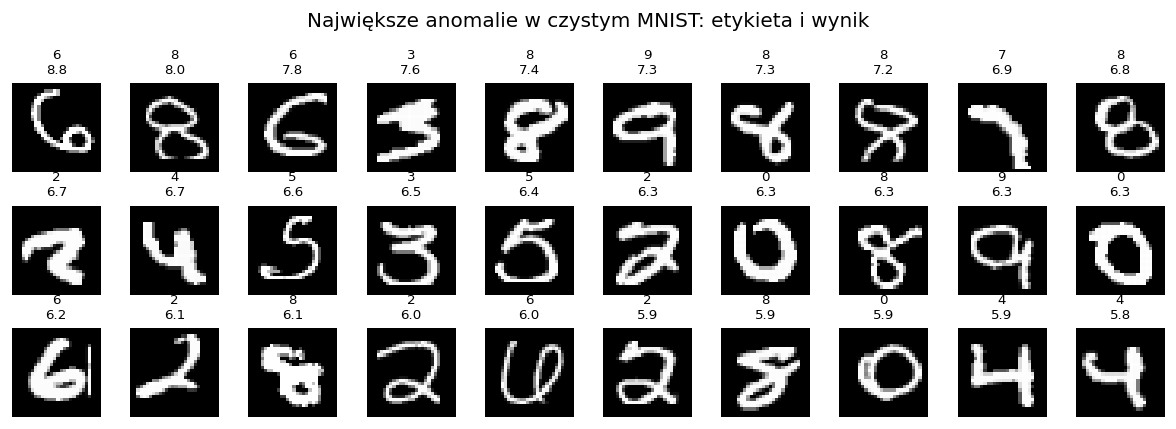

In [5]:
mnist_scores = detector.score(X_test_flat)
top_mnist = np.argsort(mnist_scores)[-30:][::-1]

print("Statystyki wyniku anomalii na czystym MNIST:")
for q in [0.50, 0.90, 0.95, 0.99, 0.995]:
    print(f"kwantyl {q:>5.3f}: {np.quantile(mnist_scores, q):8.3f}")

fig, axes = plt.subplots(3, 10, figsize=(10, 3.6))
for ax, idx in zip(axes.ravel(), top_mnist):
    ax.imshow(X_test[idx], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{y_test[idx]}\n{mnist_scores[idx]:.1f}", fontsize=8)
    ax.axis("off")
plt.suptitle("Największe anomalie w czystym MNIST: etykieta i wynik")
plt.tight_layout()

## Obce obrazki dodawane do MNIST

Tworzymy ręcznie zestaw prostych rysunków 28 x 28, które nie są cyframi. Każdy typ rysunku ma kilka wariantów przez małe przesunięcia i obroty. Dzięki temu ocena nie zależy od jednego konkretnego obrazka.

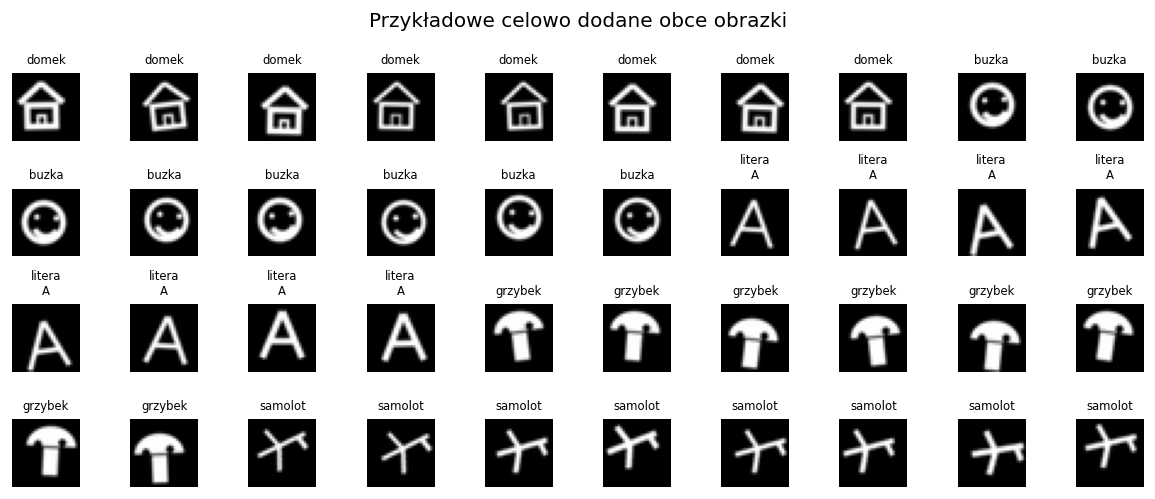

In [6]:
S = 4
BIG = 28 * S


def p(x, y):
    return (int(round(x * S)), int(round(y * S)))


def new_canvas():
    return Image.new("L", (BIG, BIG), 0)


def downsample(image):
    image = image.filter(ImageFilter.GaussianBlur(radius=0.35 * S))
    return image.resize((28, 28), Image.Resampling.LANCZOS)


def jitter_image(image, rng):
    angle = float(rng.normal(0, 5))
    shift_x = int(rng.integers(-2, 3) * S)
    shift_y = int(rng.integers(-2, 3) * S)
    image = image.rotate(angle, resample=Image.Resampling.BICUBIC, fillcolor=0)
    shifted = Image.new("L", image.size, 0)
    shifted.paste(image, (shift_x, shift_y))
    return shifted


def draw_foreign(name, rng):
    img = new_canvas()
    d = ImageDraw.Draw(img)
    w = int(rng.integers(7, 11))
    white = 255

    if name == "domek":
        d.polygon([p(5, 13), p(14, 5), p(23, 13)], outline=white, fill=0)
        d.rectangle([p(7, 13), p(21, 24)], outline=white, width=w)
        d.line([p(5, 13), p(14, 5), p(23, 13)], fill=white, width=w)
        d.rectangle([p(12, 18), p(16, 24)], outline=white, width=w // 2)
    elif name == "buzka":
        d.ellipse([*p(5, 5), *p(23, 23)], outline=white, width=w)
        d.ellipse([*p(10, 11), *p(12, 13)], fill=white)
        d.ellipse([*p(18, 11), *p(20, 13)], fill=white)
        d.arc([*p(9, 9), *p(21, 21)], start=25, end=155, fill=white, width=w)
    elif name == "litera_A":
        d.line([p(6, 24), p(14, 5), p(22, 24)], fill=white, width=w)
        d.line([p(9, 17), p(19, 17)], fill=white, width=w)
    elif name == "grzybek":
        d.pieslice([*p(4, 5), *p(24, 21)], start=180, end=360, fill=white)
        d.rectangle([*p(11, 14), *p(17, 25)], fill=white)
        d.ellipse([*p(7, 11), *p(10, 14)], fill=0)
        d.ellipse([*p(17, 10), *p(20, 13)], fill=0)
    elif name == "samolot":
        d.line([p(4, 15), p(24, 8)], fill=white, width=w)
        d.line([p(13, 12), p(8, 5)], fill=white, width=w)
        d.line([p(13, 12), p(12, 22)], fill=white, width=w)
        d.line([p(21, 9), p(24, 14)], fill=white, width=w)
    elif name == "kreska":
        d.line([p(3, 14), p(25, 14)], fill=white, width=int(1.4 * w))
    elif name == "cztery_kolka":
        for x in [7, 17]:
            for y in [7, 17]:
                d.ellipse([*p(x, y), *p(x + 6, y + 6)], outline=white, width=w)
    elif name == "gwiazda":
        pts = [p(14, 4), p(17, 11), p(25, 11), p(19, 16), p(22, 24), p(14, 19), p(6, 24), p(9, 16), p(3, 11), p(11, 11)]
        d.line(pts + [pts[0]], fill=white, width=w)
    elif name == "serce":
        d.ellipse([*p(5, 5), *p(15, 15)], fill=white)
        d.ellipse([*p(13, 5), *p(23, 15)], fill=white)
        d.polygon([p(5, 12), p(23, 12), p(14, 25)], fill=white)
    elif name == "spirala":
        for box, start in [((5, 5, 23, 23), 0), ((8, 8, 20, 20), 180), ((11, 11, 17, 17), 0)]:
            d.arc([*p(box[0], box[1]), *p(box[2], box[3])], start=start, end=start + 280, fill=white, width=w)
    else:
        raise ValueError(name)

    img = jitter_image(img, rng)
    arr = np.asarray(downsample(img), dtype=np.float32) / 255.0
    return np.clip(arr, 0.0, 1.0)


foreign_names = ["domek", "buzka", "litera_A", "grzybek", "samolot", "kreska", "cztery_kolka", "gwiazda", "serce", "spirala"]
foreign_images = []
foreign_labels = []
for name in foreign_names:
    for _ in range(8):
        foreign_images.append(draw_foreign(name, rng))
        foreign_labels.append(name)

foreign_images = np.stack(foreign_images)
foreign_labels = np.array(foreign_labels)
foreign_flat = foreign_images.reshape(len(foreign_images), -1)

fig, axes = plt.subplots(4, 10, figsize=(10, 4.2))
for ax, image, name in zip(axes.ravel(), foreign_images[:40], foreign_labels[:40]):
    ax.imshow(image, cmap="gray", vmin=0, vmax=1)
    ax.set_title(name.replace("_", "\n"), fontsize=7)
    ax.axis("off")
plt.suptitle("Przykładowe celowo dodane obce obrazki")
plt.tight_layout()

## Przypadek b: MNIST z dorzuconymi obcymi obrazkami

Mieszamy pełny testowy MNIST z obcymi obrazkami i sprawdzamy, czy najwyższe wyniki anomalii trafiają właśnie w te obce przykłady. Skuteczność mierzymy przez:

- `precision@N` i `recall@N`, gdzie `N` to liczba obcych obrazków,
- `precision@kN` i `recall@kN` dla trochę dłuższej listy podejrzeń,
- ROC AUC,
- average precision.

In [7]:
def roc_auc_manual(y_true, scores):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores)
    order = np.argsort(scores)[::-1]
    y_sorted = y_true[order]
    positives = y_sorted.sum()
    negatives = len(y_sorted) - positives
    if positives == 0 or negatives == 0:
        return np.nan

    tpr = np.r_[0.0, np.cumsum(y_sorted) / positives]
    fpr = np.r_[0.0, np.cumsum(1 - y_sorted) / negatives]
    return np.trapezoid(tpr, fpr)


def average_precision_manual(y_true, scores):
    y_true = np.asarray(y_true).astype(int)
    scores = np.asarray(scores)
    order = np.argsort(scores)[::-1]
    y_sorted = y_true[order]
    positives = y_sorted.sum()
    if positives == 0:
        return np.nan
    precision_at_k = np.cumsum(y_sorted) / (np.arange(len(y_sorted)) + 1)
    return (precision_at_k * y_sorted).sum() / positives


mixed_images = np.concatenate([X_test, foreign_images], axis=0)
mixed_flat = mixed_images.reshape(len(mixed_images), -1)
is_foreign = np.r_[np.zeros(len(X_test), dtype=int), np.ones(len(foreign_images), dtype=int)]
mixed_names = np.r_[np.array([f"MNIST {label}" for label in y_test]), foreign_labels]

mixed_scores = detector.score(mixed_flat)
N = len(foreign_images)
top_n = np.argsort(mixed_scores)[-N:][::-1]

def top_k_report(k):
    top = np.argsort(mixed_scores)[-k:][::-1]
    precision = is_foreign[top].mean()
    recall = is_foreign[top].sum() / N
    return precision, recall


precision_at_n, recall_at_n = top_k_report(N)
roc_auc = roc_auc_manual(is_foreign, mixed_scores)
avg_precision = average_precision_manual(is_foreign, mixed_scores)

print(f"Liczba cyfr MNIST w mieszance: {len(X_test)}")
print(f"Liczba obcych obrazków: {N}")
print(f"precision@N:  {precision_at_n:.3f}")
print(f"recall@N:     {recall_at_n:.3f}")
for multiplier in [2, 5, 10]:
    precision_k, recall_k = top_k_report(multiplier * N)
    print(f"precision@{multiplier}N: {precision_k:.3f}   recall@{multiplier}N: {recall_k:.3f}")
print(f"ROC AUC:     {roc_auc:.3f}")
print(f"AvgPrec:     {avg_precision:.3f}")

threshold = np.partition(mixed_scores, -N)[-N]
print(f"Próg odpowiadający pierwszym N podejrzeniom: {threshold:.3f}")

Liczba cyfr MNIST w mieszance: 10000
Liczba obcych obrazków: 80
precision@N:  0.487
recall@N:     0.487
precision@2N: 0.300   recall@2N: 0.600
precision@5N: 0.142   recall@5N: 0.713
precision@10N: 0.084   recall@10N: 0.838
ROC AUC:     0.970
AvgPrec:     0.535
Próg odpowiadający pierwszym N podejrzeniom: 5.609


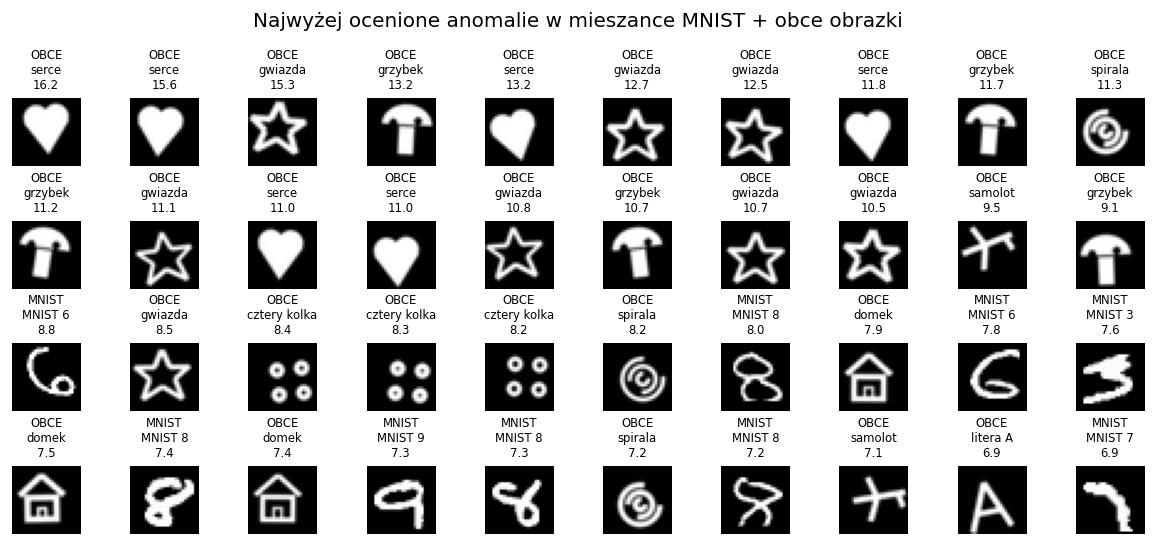

In [8]:
fig, axes = plt.subplots(4, 10, figsize=(10, 4.6))
for ax, idx in zip(axes.ravel(), np.argsort(mixed_scores)[-40:][::-1]):
    ax.imshow(mixed_images[idx], cmap="gray", vmin=0, vmax=1)
    title = mixed_names[idx].replace("_", " ")
    mark = "OBCE" if is_foreign[idx] else "MNIST"
    ax.set_title(f"{mark}\n{title}\n{mixed_scores[idx]:.1f}", fontsize=7)
    ax.axis("off")
plt.suptitle("Najwyżej ocenione anomalie w mieszance MNIST + obce obrazki")
plt.tight_layout()

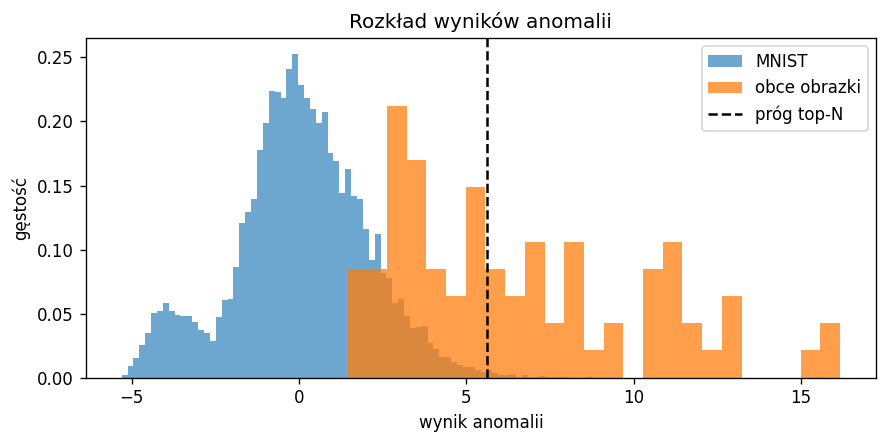

In [9]:
foreign_scores = mixed_scores[is_foreign == 1]
mnist_only_scores = mixed_scores[is_foreign == 0]

plt.figure(figsize=(7.5, 3.8))
plt.hist(mnist_only_scores, bins=80, alpha=0.65, label="MNIST", density=True)
plt.hist(foreign_scores, bins=25, alpha=0.75, label="obce obrazki", density=True)
plt.axvline(threshold, color="black", linestyle="--", linewidth=1.5, label="próg top-N")
plt.xlabel("wynik anomalii")
plt.ylabel("gęstość")
plt.title("Rozkład wyników anomalii")
plt.legend()
plt.tight_layout()

In [10]:
print("Wykrywalność według typu obcego obrazka przy progu top-N:")
for name in foreign_names:
    mask = foreign_labels == name
    detected = (foreign_scores[mask] >= threshold).mean()
    print(f"{name:14s}: {detected:.3f}  średni score={foreign_scores[mask].mean():7.2f}")

Wykrywalność według typu obcego obrazka przy progu top-N:
domek         : 0.750  średni score=   6.29
buzka         : 0.000  średni score=   2.53
litera_A      : 0.125  średni score=   3.53
grzybek       : 0.625  średni score=   8.77
samolot       : 0.375  średni score=   5.54
kreska        : 0.000  średni score=   3.18
cztery_kolka  : 0.750  średni score=   6.67
gwiazda       : 1.000  średni score=  11.53
serce         : 0.875  średni score=  11.01
spirala       : 0.375  średni score=   6.26


## Wnioski

Detektor nie potrzebuje przykładów anomalii podczas uczenia. Uczy się tylko geometrii normalnych cyfr MNIST. W czystym MNIST najwyższe wyniki dostają nietypowe lub trudne cyfry, co jest rozsądnym zachowaniem, bo w tym wariancie nie ma prawdziwych obcych klas. Po dorzuceniu ręcznie narysowanych obiektów detektor powinien przesunąć większość takich obrazków na początek rankingu anomalii. Najtrudniejsze są obiekty podobne do prostych cyfr, np. pojedyncza kreska może przypominać cyfrę 1, a niektóre kółka mogą przypominać 0 lub 8.